<a href="https://colab.research.google.com/github/douglas-varjao/TechChallenge-Fase3-AtrasosVoos/blob/main/TechChallenge_Fase3_AtrasosVoos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ✈️ Tech Challenge Fase 3 — Previsão de Atrasos e Análise Operacional

Este notebook unifica o pipeline completo de Machine Learning, abordando desde o tratamento inicial até a explicabilidade avançada dos modelos.

## 00. Setup e Bibliotecas
Instalação de pacotes externos, importação de módulos, montagem do diretório e padronização visual.

In [ ]:
# ── 1. Instalações ───────────────────────────────────────────────────────────
!pip install holidays xgboost lightgbm shap -q

In [ ]:

# ── 2. Manipulação de Dados e Visualização ───────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── 3. Utilitários e Feature Engineering ─────────────────────────────────────
import holidays
import warnings
warnings.filterwarnings('ignore') # Mantém o log limpo de depreciações futuras

# ── 4. Machine Learning: Pré-processamento e Avaliação ───────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    roc_auc_score, precision_score, recall_score,
    RocCurveDisplay, PrecisionRecallDisplay, silhouette_score
)

# ── 5. Machine Learning: Modelos Supervisionados ─────────────────────────────
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
import lightgbm as lgb

# ── 6. Machine Learning: Modelos Não Supervisionados ─────────────────────────
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ── 7. Explicabilidade (XAI) ─────────────────────────────────────────────────
import shap

# ── 8. Configuração do Ambiente e Paleta Visual ──────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# Paleta consistente para padronização de todos os gráficos
COR_PRINCIPAL = '#2E86AB'
COR_ALERTA    = '#E84855'
COR_OK        = '#3BB273'
PALETTE_CLUSTERS = ['#2E86AB','#E84855','#3BB273','#F4A261','#9B5DE5','#00BBF9']
sns.set_theme(style="whitegrid")

print('✅ Passo 00 Concluído: Bibliotecas carregadas, paleta definida e Drive montado!')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Passo 00 Concluído: Bibliotecas carregadas, paleta definida e Drive montado!


## 01. Carregamento e Limpeza Inicial dos Dados

Para garantir a qualidade da modelagem, aplicamos três regras de negócio imediatas:
1. **Remoção de cancelados e desviados:** São eventos de natureza diferente do atraso operacional.
2. **Remoção de nulos no alvo:** Sem a variável `ARRIVAL_DELAY`, não há o que o modelo aprender.
3. **Filtro de *Outliers*:** Remoção de atrasos superiores a 600 minutos (10 horas) para evitar distorções nas distribuições das *features*.

In [ ]:
# ── 1. Carregamento dos Dados ────────────────────────────────────────────────

PATH = 'drive/MyDrive/TechChallenge_Fase3_AtrasosVoos/database/'

try:
    fl = pd.read_csv(PATH + 'flights.csv', low_memory=False)
    al = pd.read_csv(PATH + 'airlines.csv')
    ap = pd.read_csv(PATH + 'airports.csv')

    print('✅ Dados carregados com sucesso!')
    print(f'flights  : {fl.shape[0]:,} linhas × {fl.shape[1]} colunas')
    print(f'airlines : {al.shape[0]:,} linhas')
    print(f'airports : {ap.shape[0]:,} linhas\n')
except FileNotFoundError:
    print('❌ Erro: Arquivos não encontrados. Verifique o caminho (PATH).')

# ── 2. Limpeza Inicial (Regras de Negócio) ───────────────────────────────────
df_voos = fl.copy()
n_inicial = len(df_voos)

# Regra 1: Remover cancelados e desviados
df_voos = df_voos[(df_voos['CANCELLED'] == 0) & (df_voos['DIVERTED'] == 0)]
print(f'Após remover cancelados/desviados : {len(df_voos):>10,}  (- {n_inicial - len(df_voos):,} registros)')

# Regra 2: Remover linhas sem o Target (ARRIVAL_DELAY)
df_voos = df_voos.dropna(subset=['ARRIVAL_DELAY'])
print(f'Após remover sem ARRIVAL_DELAY    : {len(df_voos):>10,}')

# Regra 3: Remover outliers extremos (> 600 min)
df_voos = df_voos[df_voos['ARRIVAL_DELAY'] <= 600]
print(f'Após remover outliers > 600 min   : {len(df_voos):>10,}')

print('-' * 60)
print(f'✅ Limpeza concluída. Total de linhas válidas: {len(df_voos):,}')

✅ Dados carregados com sucesso!
flights  : 5,819,079 linhas × 31 colunas
airlines : 14 linhas
airports : 322 linhas

Após remover cancelados/desviados :  5,714,008  (- 105,071 registros)
Após remover sem ARRIVAL_DELAY    :  5,714,008
Após remover outliers > 600 min   :  5,712,660
------------------------------------------------------------
✅ Limpeza concluída. Total de linhas válidas: 5,712,660


## 02. Inteligência Operacional: Clusterização de Aeroportos (K-Means)

Atendendo ao requisito de **Aprendizado Não Supervisionado**, aplicamos o algoritmo K-Means para identificar perfis operacionais de aeroportos. Em vez de tratar todos os locais de forma genérica, agrupamos os aeroportos por comportamento de atraso, volume e causas (clima, efeito cascata, sistema, etc.).

Esta etapa:
1. Extrai o "DNA" de cada aeroporto com base nas métricas da FAA.
2. Agrupa os perfis usando K-Means (com K=4 validado pelas métricas de Inércia e Silhouette).
3. Cria uma nova *feature* (`CLUSTER_AERO`) que será injetada nos modelos supervisionados.

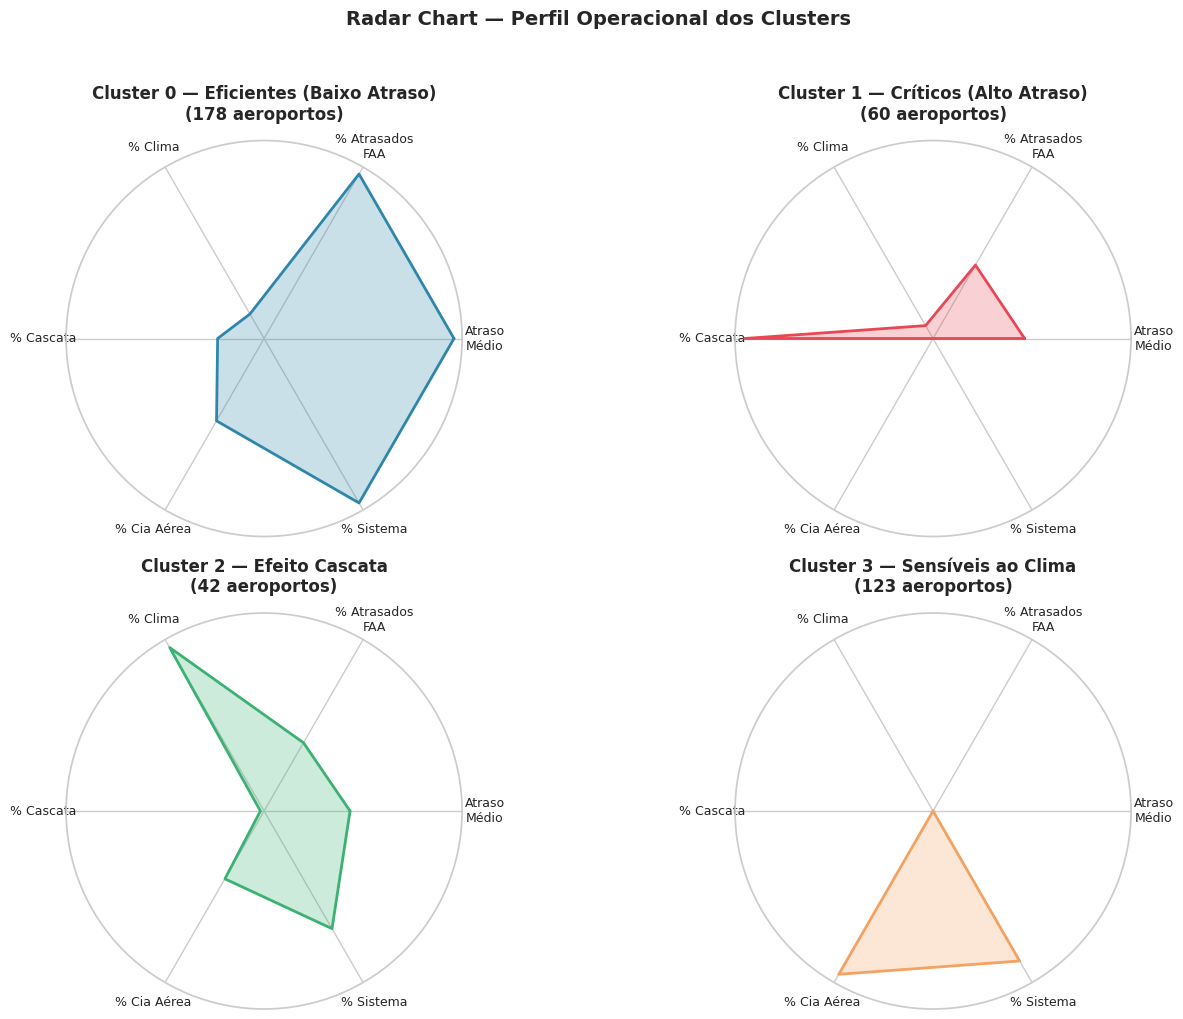

✅ Clusterização concluída e feature CLUSTER_AERO acoplada à base de voos!


In [ ]:
# ── 1. Construção do perfil por aeroporto ────────────────────────────────────
cols_causa = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']

# Criamos uma cópia temporária preenchendo as causas de atraso (NaN = 0 min de atraso)
df_op = df_voos.copy()
df_op['ATRASADO_FAA'] = (df_op['ARRIVAL_DELAY'] > 15).astype(int)
df_op[cols_causa] = df_op[cols_causa].fillna(0)

# Agregação por aeroporto
perfil = df_op.groupby('ORIGIN_AIRPORT').agg(
    vol_voos          = ('FLIGHT_NUMBER', 'count'),
    atraso_medio      = ('ARRIVAL_DELAY', 'mean'),
    perc_atrasado_faa = ('ATRASADO_FAA', 'mean')
).reset_index()

# Recalculando os totais de minutos por causa
for col in cols_causa:
    perfil[f'sum_{col}'] = df_op.groupby('ORIGIN_AIRPORT')[col].sum().values

# Calculando a porcentagem de cada causa em relação ao total de atrasos do aeroporto
perfil['sum_total'] = perfil[[f'sum_{c}' for c in cols_causa]].sum(axis=1).replace(0, np.nan)
perfil['perc_sistema'] = perfil['sum_AIR_SYSTEM_DELAY'] / perfil['sum_total']
perfil['perc_cia']     = perfil['sum_AIRLINE_DELAY'] / perfil['sum_total']
perfil['perc_cascata'] = perfil['sum_LATE_AIRCRAFT_DELAY'] / perfil['sum_total']
perfil['perc_clima']   = perfil['sum_WEATHER_DELAY'] / perfil['sum_total']

# Filtro: Apenas aeroportos com volume mínimo (>= 500 voos) para evitar ruído estatístico
perfil = perfil[perfil['vol_voos'] >= 500].dropna().copy()
perfil['log_vol'] = np.log1p(perfil['vol_voos'])

# ── 2. Aplicação do K-Means ──────────────────────────────────────────────────
FEATURES_CLUSTER = [
    'atraso_medio', 'perc_atrasado_faa', 'log_vol',
    'perc_clima', 'perc_cascata', 'perc_cia', 'perc_sistema'
]

X_cl = perfil[FEATURES_CLUSTER].values
scaler_cl = StandardScaler()
X_cl_sc = scaler_cl.fit_transform(X_cl)

# Fixamos K=4 com base na análise prévia do Silhouette Score do Murillo
K_FINAL = 4
km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20)
perfil['CLUSTER'] = km_final.fit_predict(X_cl_sc)

NOMES_CLUSTER = {
    0: 'Eficientes (Baixo Atraso)',
    1: 'Críticos (Alto Atraso)',
    2: 'Efeito Cascata',
    3: 'Sensíveis ao Clima'
}
perfil['CLUSTER_NOME'] = perfil['CLUSTER'].map(NOMES_CLUSTER)

# ── 3. Radar Chart para Explicabilidade ──────────────────────────────────────
radar_features = ['atraso_medio', 'perc_atrasado_faa', 'perc_clima', 'perc_cascata', 'perc_cia', 'perc_sistema']
radar_labels   = ['Atraso\nMédio', '% Atrasados\nFAA', '% Clima', '% Cascata', '% Cia Aérea', '% Sistema']

radar_data = perfil.groupby('CLUSTER')[radar_features].mean()
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min() + 1e-9)

N = len(radar_features)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(2, 2, figsize=(14, 10), subplot_kw=dict(polar=True))
axes = axes.flatten()

for i, (cluster_id, row) in enumerate(radar_norm.iterrows()):
    ax = axes[i]
    values = row.tolist() + row.tolist()[:1]
    ax.plot(angles, values, color=PALETTE_CLUSTERS[i], lw=2)
    ax.fill(angles, values, color=PALETTE_CLUSTERS[i], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, fontsize=9)
    ax.set_yticks([]) # Oculta os anéis internos para visual mais limpo
    nome = NOMES_CLUSTER.get(cluster_id)
    n_ap = len(perfil[perfil['CLUSTER'] == cluster_id])
    ax.set_title(f'Cluster {cluster_id} — {nome}\n({n_ap} aeroportos)', fontweight='bold', pad=15)

plt.suptitle('Radar Chart — Perfil Operacional dos Clusters', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── 4. Integração ao Dataset Principal (Feature Engineering) ─────────────────
# Mapeamos o cluster de volta para os voos. Aeroportos pequenos recebem o cluster 0 (Eficientes/Menor Risco)
df_voos = df_voos.merge(perfil[['ORIGIN_AIRPORT', 'CLUSTER']], on='ORIGIN_AIRPORT', how='left')
df_voos['CLUSTER_AERO'] = df_voos['CLUSTER'].fillna(0).astype(int)
df_voos = df_voos.drop(columns=['CLUSTER'])

print('✅ Clusterização concluída e feature CLUSTER_AERO acoplada à base de voos!')

## 03. Redução de Dimensionalidade e Visualização (PCA)

Para validar visualmente a eficácia da nossa clusterização, aplicamos a **Análise de Componentes Principais (PCA)**.

O PCA projeta as 7 variáveis originais de perfil dos aeroportos em um plano 2D (PC1 e PC2). Isso nos permite:
1. Analisar a **variância explicada** por cada componente.
2. Visualizar a **separabilidade dos clusters** no espaço reduzido.
3. Entender o peso (através do *Biplot*) de cada variável original na formação das novas componentes.

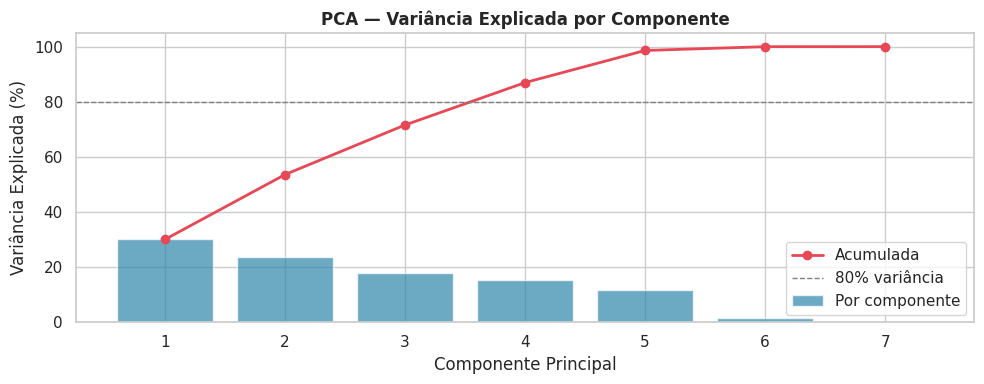

In [ ]:
# ── 1. PCA Completo: Análise de Variância Explicada ──────────────────────────
pca_full = PCA(random_state=42)
pca_full.fit(X_cl_sc) # X_cl_sc vem do nosso Passo 02

var_explicada = pca_full.explained_variance_ratio_
var_acumulada = np.cumsum(var_explicada)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(1, len(var_explicada)+1), var_explicada * 100,
       color=COR_PRINCIPAL, alpha=0.7, label='Por componente')
ax.plot(range(1, len(var_acumulada)+1), var_acumulada * 100,
        'o-', color=COR_ALERTA, lw=2, label='Acumulada')
ax.axhline(80, color='gray', linestyle='--', lw=1, label='80% variância')
ax.set_xlabel('Componente Principal')
ax.set_ylabel('Variância Explicada (%)')
ax.set_title('PCA — Variância Explicada por Componente', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()





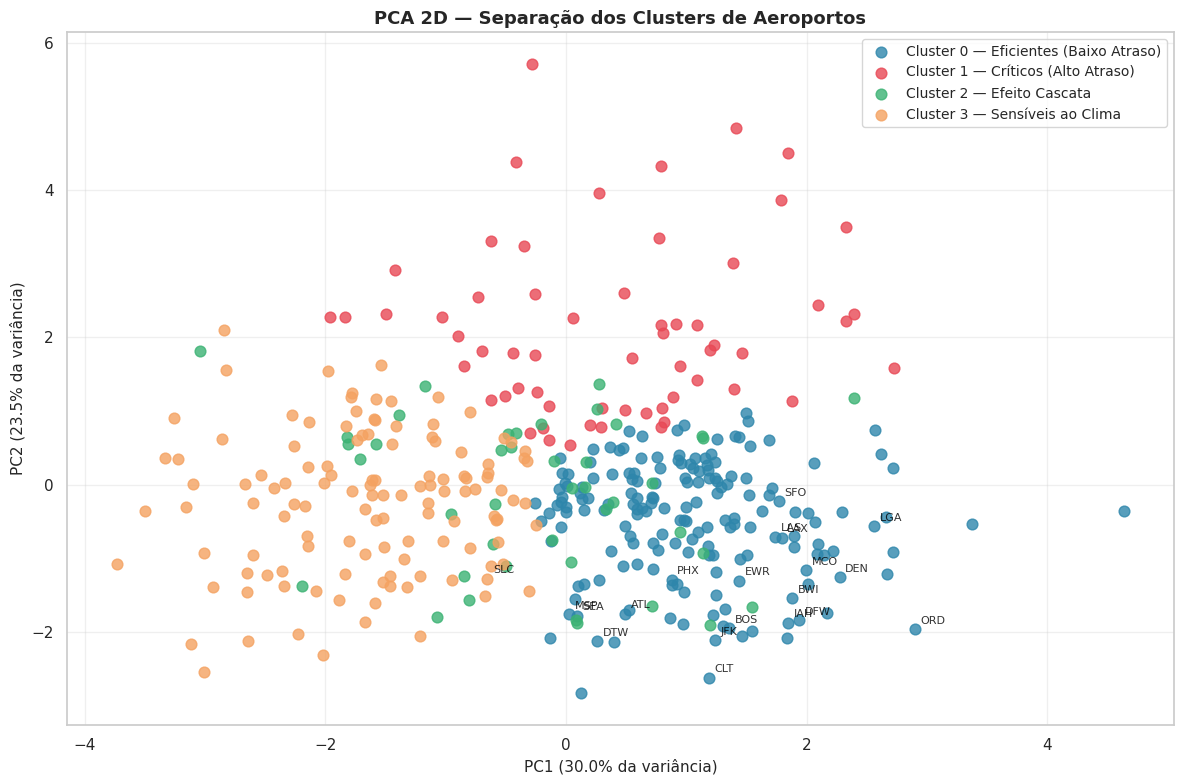

In [ ]:
# ── 2. Projeção 2D: Visualização dos Clusters ────────────────────────────────
pca_2d = PCA(n_components=2, random_state=42)
coords_2d = pca_2d.fit_transform(X_cl_sc)

perfil['PC1'] = coords_2d[:, 0]
perfil['PC2'] = coords_2d[:, 1]

fig, ax = plt.subplots(figsize=(12, 8))

for c in sorted(perfil['CLUSTER'].unique()):
    sub = perfil[perfil['CLUSTER'] == c]
    ax.scatter(sub['PC1'], sub['PC2'],
               color=PALETTE_CLUSTERS[c], s=60, alpha=0.8,
               label=f"Cluster {c} — {perfil[perfil['CLUSTER'] == c]['CLUSTER_NOME'].iloc[0]}")

# Rotulando os top 20 aeroportos por volume de voos para dar contexto de negócio
top_airports = perfil.nlargest(20, 'vol_voos')
for _, row in top_airports.iterrows():
    ax.annotate(row['ORIGIN_AIRPORT'],
                xy=(row['PC1'], row['PC2']),
                xytext=(4, 4), textcoords='offset points',
                fontsize=8, color='black', alpha=0.8)

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% da variância)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% da variância)', fontsize=11)
ax.set_title('PCA 2D — Separação dos Clusters de Aeroportos', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

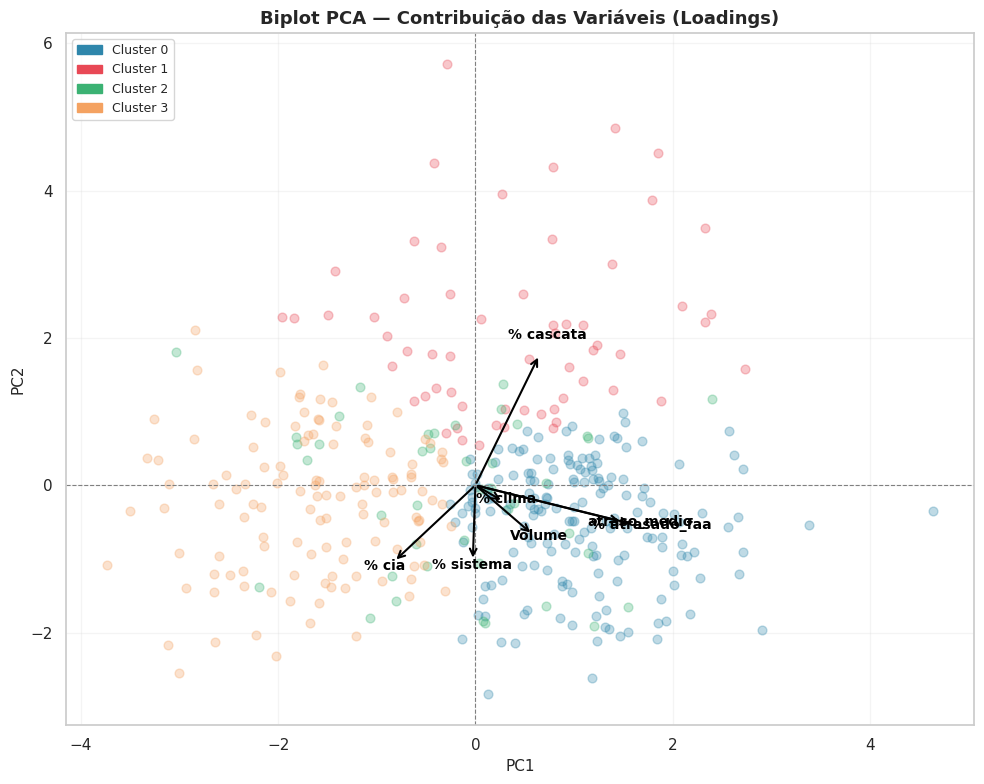

✅ Passo 03 Concluído: Redução de dimensionalidade aplicada e interpretada!


In [ ]:
# ── 3. Biplot: Direção e Força das Features Originais ────────────────────────
loadings = pca_2d.components_.T
escala = 2.5

fig, ax = plt.subplots(figsize=(10, 8))

# Plot base dos aeroportos
for c in sorted(perfil['CLUSTER'].unique()):
    sub = perfil[perfil['CLUSTER'] == c]
    ax.scatter(sub['PC1'], sub['PC2'], color=PALETTE_CLUSTERS[c], s=40, alpha=0.3)

# Plot dos vetores de features (Loadings)
for i, feat in enumerate(FEATURES_CLUSTER):
    ax.annotate('', xy=(loadings[i, 0]*escala, loadings[i, 1]*escala), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
    ax.text(loadings[i, 0]*escala*1.12, loadings[i, 1]*escala*1.12,
            feat.replace('perc_', '% ').replace('log_vol', 'Volume'),
            fontsize=10, ha='center', color='black', fontweight='bold')

ax.axhline(0, color='gray', lw=0.8, linestyle='--')
ax.axvline(0, color='gray', lw=0.8, linestyle='--')
ax.set_xlabel('PC1', fontsize=11)
ax.set_ylabel('PC2', fontsize=11)
ax.set_title('Biplot PCA — Contribuição das Variáveis (Loadings)', fontsize=13, fontweight='bold')

patches = [mpatches.Patch(color=PALETTE_CLUSTERS[c], label=f'Cluster {c}') for c in sorted(perfil['CLUSTER'].unique())]
ax.legend(handles=patches, fontsize=9, loc='upper left')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print('✅ Passo 03 Concluído: Redução de dimensionalidade aplicada e interpretada!')

## 04. Base de Clima Externa

Dados obtidos via [Open-Meteo Archive API](https://open-meteo.com/) — gratuita, sem autenticação.  
**Estratégia:** uma chamada por aeroporto com range anual completo → ~322 chamadas no total (vs. ~117k se fosse por dia).

> ⚠️ **Rode o bloco de geração apenas UMA vez.** O CSV é salvo no Drive e reutilizado em todas as execuções subsequentes.

In [ ]:
# ── GERAÇÃO DO CLIMA — rodar apenas 1x ───────────────────────────────────────
# Descomente este bloco na primeira execução

# import requests, time
# from tqdm import tqdm
#
# aeroportos_usados = df['ORIGIN_AIRPORT'].unique()
# coords = (
#     airports[airports['IATA_CODE'].isin(aeroportos_usados)]
#     [['IATA_CODE', 'LATITUDE', 'LONGITUDE']].dropna().reset_index(drop=True)
# )
# print(f'Aeroportos para buscar: {len(coords)}')
#
# def busca_clima_ano(iata, lat, lon):
#     url = (
#         f'https://archive-api.open-meteo.com/v1/archive'
#         f'?latitude={lat}&longitude={lon}'
#         f'&start_date=2015-01-01&end_date=2015-12-31'
#         f'&daily=precipitation_sum,windspeed_10m_max,temperature_2m_max'
#         f'&timezone=America/New_York'
#     )
#     try:
#         r = requests.get(url, timeout=15).json()
#         return pd.DataFrame({
#             'data'            : r['daily']['time'],
#             'chuva_mm'        : r['daily']['precipitation_sum'],
#             'vento_kmh'       : r['daily']['windspeed_10m_max'],
#             'temperatura_max' : r['daily']['temperature_2m_max'],
#             'ORIGIN_AIRPORT'  : iata
#         })
#     except Exception as e:
#         print(f'Erro em {iata}: {e}')
#         return None
#
# resultados = []
# for _, row in tqdm(coords.iterrows(), total=len(coords)):
#     dados = busca_clima_ano(row['IATA_CODE'], row['LATITUDE'], row['LONGITUDE'])
#     if dados is not None:
#         resultados.append(dados)
#     time.sleep(0.2)
#
# clima_2015 = pd.concat(resultados, ignore_index=True)
# clima_2015.to_csv(PATH + 'clima_2015.csv', index=False)
# print(f'Salvo: {len(clima_2015):,} registros')

print('Bloco de geração comentado — carregando CSV existente na próxima célula.')

Bloco de geração comentado — carregando CSV existente na próxima célula.


## 04.1 Feature Engineering e Dados Externos (Clima)

Transformação de dados brutos em variáveis preditivas para captar a complexidade do sistema aéreo antes da descolagem:

| Atributo | Categoria | Racional de Negócio |
|---|---|---|
| `HORA` / `FAIXA_HORA` | Temporal | Atrasos acumulam-se ao longo do dia (efeito cascata). |
| `IS_HOLIDAY` / `EVE` | Calendário | Feriados federais e vésperas alteram o volume e a ocupação da malha. |
| `HIST_ATRASO_ROTA` | Histórico | Média móvel dos últimos 7 voos da rota. Termómetro operacional. |
| `VOOS_NO_DIA` | Fluxo | Congestionamento sistémico diário por aeroporto. |
| `CLIMA` | Externo | Chuva e vento impactam diretamente a segurança e capacidade. |
| `CLUSTER_AERO` | Inteligência | (Do K-Means) Perfil de risco operacional do aeroporto de origem. |

In [ ]:
# ── 1. Carregamento da Base de Clima (Open-Meteo) ────────────────────────────
try:
    clima_2015 = pd.read_csv(PATH + 'clima_2015.csv')
    clima_2015['data'] = pd.to_datetime(clima_2015['data'])
    clima_2015['MONTH'] = clima_2015['data'].dt.month
    clima_2015['DAY']   = clima_2015['data'].dt.day
    print(f'✅ Dados de clima carregados: {len(clima_2015):,} registos')
except FileNotFoundError:
    print('⚠️ Aviso: clima_2015.csv não encontrado. Execute o script de extração da API primeiro.')

# ── 2. Variáveis Temporais (Hora e Risco Horário) ────────────────────────────
df_voos['HORA'] = (df_voos['SCHEDULED_DEPARTURE'] // 100).clip(0, 23).astype(int)

def classifica_hora(hora):
    if 5 <= hora <= 9: return 0    # Baixo risco (manhã)
    elif 14 <= hora <= 21: return 2 # Alto risco (acumulação à tarde/noite)
    else: return 1                  # Risco médio

df_voos['FAIXA_HORA'] = df_voos['HORA'].apply(classifica_hora)

# ── 3. Variáveis de Calendário (Feriados EUA) ────────────────────────────────
feriados_eua = {
    (1,1),(1,19),(2,16),(5,25),(7,3),(7,4),(9,7),(10,12),(11,11),(11,26),(12,25)
}
vesperas = set(((pd.Timestamp(2015, m, d) - pd.Timedelta(days=1)).month,
                (pd.Timestamp(2015, m, d) - pd.Timedelta(days=1)).day) for m, d in feriados_eua)

df_voos['IS_HOLIDAY']     = df_voos.apply(lambda r: int((r['MONTH'], r['DAY']) in feriados_eua), axis=1)
df_voos['IS_EVE_HOLIDAY'] = df_voos.apply(lambda r: int((r['MONTH'], r['DAY']) in vesperas), axis=1)
df_voos['IS_PEAK_SEASON'] = df_voos['MONTH'].isin([6, 7, 11, 12]).astype(int)
df_voos['IS_WEEKEND']     = df_voos['DAY_OF_WEEK'].isin([6, 7]).astype(int)

# ── 4. Histórico de Cascata e Congestionamento ───────────────────────────────
# Ordenação cronológica obrigatória antes da janela móvel
df_voos = df_voos.sort_values(['AIRLINE', 'ORIGIN_AIRPORT', 'MONTH', 'DAY', 'HORA']).reset_index(drop=True)

df_voos['HIST_ATRASO_ROTA'] = (
    df_voos.groupby(['AIRLINE', 'ORIGIN_AIRPORT'])['ARRIVAL_DELAY']
           .transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean())
)

congestionamento = df_voos.groupby(['ORIGIN_AIRPORT', 'MONTH', 'DAY']).size().reset_index(name='VOOS_NO_DIA')
df_voos = df_voos.merge(congestionamento, on=['ORIGIN_AIRPORT', 'MONTH', 'DAY'], how='left')

# ── 5. Junção com Clima e Definição do Target ────────────────────────────────
if 'clima_2015' in locals():
    df_voos = df_voos.merge(
        clima_2015[['ORIGIN_AIRPORT', 'MONTH', 'DAY', 'chuva_mm', 'vento_kmh', 'temperatura_max']],
        on=['ORIGIN_AIRPORT', 'MONTH', 'DAY'], how='left'
    )

    # Preenchimento de nulos no clima (imputação simples e robusta)
    df_voos['chuva_mm']        = df_voos['chuva_mm'].fillna(0)
    df_voos['vento_kmh']       = df_voos['vento_kmh'].fillna(df_voos['vento_kmh'].median())
    df_voos['temperatura_max'] = df_voos['temperatura_max'].fillna(df_voos['temperatura_max'].median())

# Variável Alvo Final: Atraso superior a 15 min (Regra FAA)
df_voos['ATRASADO_FAA'] = (df_voos['ARRIVAL_DELAY'] > 15).astype(int)

print('✅ Feature Engineering concluída!')
print(f'   Taxa de Atraso (FAA): {df_voos["ATRASADO_FAA"].mean()*100:.1f}%')


✅ Dados de clima carregados: 116,070 registos
✅ Feature Engineering concluída!
   Taxa de Atraso (FAA): 17.9%


## 05. Preparação do Dataset e Separação Treino/Teste

Para assegurar o rigor técnico e a comparabilidade entre os algoritmos, o *split* de treino e teste é realizado uma única vez.

Procedimentos aplicados:
1. **Amostragem (Opcional):** Controlo do volume de dados para evitar estrangulamentos de RAM.
2. **Encoding:** Transformação de variáveis textuais (Companhias e Aeroportos) em formato numérico (`LabelEncoder`).
3. **Estratificação:** Divisão 80/20 respeitando a distribuição da classe minoritária.
4. **Escalonamento:** Normalização das grandezas (`StandardScaler`), passo crucial para o modelo de Deep Learning (MLP).

In [ ]:
# ── 1. Definição de Features e Target ────────────────────────────────────────
FEATURES = [
    # Temporais e Calendário
    'MONTH', 'DAY_OF_WEEK', 'HORA', 'FAIXA_HORA',
    'IS_HOLIDAY', 'IS_EVE_HOLIDAY', 'IS_PEAK_SEASON', 'IS_WEEKEND',
    # Históricas e Operacionais
    'HIST_ATRASO_ROTA', 'VOOS_NO_DIA',
    # Identidade e Planeamento
    'AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
    'SCHEDULED_TIME', 'DISTANCE',
    # Dados Externos (Clima)
    'chuva_mm', 'vento_kmh', 'temperatura_max',
    # Inteligência do K-Means
    'CLUSTER_AERO'
]
TARGET = 'ATRASADO_FAA'

# Seleção rigorosa eliminando eventuais nulos residuais da janela móvel
df_model_final = df_voos[FEATURES + [TARGET, 'ARRIVAL_DELAY']].dropna().copy()

# Guardamos o nome original da companhia para análises de erro futuras
df_model_final['AIRLINE_ORIGINAL'] = df_model_final['AIRLINE']

# ── 2. Amostragem Estratificada (Gestão de Memória) ──────────────────────────
# DICA SÉNIOR: Se tiver RAM suficiente (ex: Colab Pro), altere para 1.0
SAMPLE_FRAC = 0.1

df_model_final = df_model_final.groupby(TARGET, group_keys=False).apply(
    lambda x: x.sample(frac=SAMPLE_FRAC, random_state=42)
)

# ── 3. Label Encoding (Variáveis Categóricas) ────────────────────────────────
for col in ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']:
    le = LabelEncoder()
    df_model_final[col] = le.fit_transform(df_model_final[col].astype(str))

# ── 4. Separação em Treino e Teste (Split Único) ─────────────────────────────
X = df_model_final[FEATURES]
y = df_model_final[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── 5. Escalonamento e Balanceamento ─────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Cálculo do peso para corrigir o desbalanceamento nativo (usado no XGB e LGBM)
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f"✅ Preparação concluída!")
print(f"   Treino : {len(X_train):,} amostras")
print(f"   Teste  : {len(X_test):,} amostras")
print(f"   Scale Pos Weight (Ajuste de Classe): {scale_pos_weight:.2f}")

✅ Preparação concluída!
   Treino : 456,821 amostras
   Teste  : 114,206 amostras
   Scale Pos Weight (Ajuste de Classe): 4.59


## 06. Modelagem Supervisionada (XGBoost, LightGBM e Rede Neural)

Treinamento de três algoritmos com arquiteturas distintas para encontrar a melhor relação entre Precisão e Recall no contexto de dados desbalanceados.

* **XGBoost:** Algoritmo de *gradient boosting* robusto, constrói árvores por nível (*level-wise*).
* **LightGBM:** Variante de *boosting* otimizada, cresce árvores por folha (*leaf-wise*), sendo mais rápida e leve.
* **MLP (Rede Neural):** Perceptron de múltiplas camadas (128 → 64 → 32), ideal para mapear interações complexas que as árvores podem ignorar.

> **Nota Técnica:** O ponto de corte (*threshold*) foi ajustado de 0.5 para 0.4. Isso torna os modelos ligeiramente mais sensíveis, diminuindo os Falsos Negativos (voos que atrasam sem aviso).

In [ ]:
# ── 1. Modelo 1: XGBoost ─────────────────────────────────────────────────────
print('Treinando XGBoost...')
xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(X_train, y_train)

xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred = (xgb_prob >= 0.4).astype(int)

# ── 2. Modelo 2: LightGBM ────────────────────────────────────────────────────
print('Treinando LightGBM...')
lgbm_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=7,
    num_leaves=63,
    min_child_samples=50,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)
# LightGBM permite early stopping nativo passando o conjunto de validação
lgbm_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

lgbm_prob = lgbm_model.predict_proba(X_test)[:, 1]
lgbm_pred = (lgbm_prob >= 0.4).astype(int)

# ── 3. Modelo 3: Rede Neural (MLP) ───────────────────────────────────────────
print('Treinando Rede Neural (MLP)...')
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,
    batch_size=2048,
    max_iter=100,
    early_stopping=True,
    random_state=42
)
# Redes neurais DEVEM receber os dados escalonados (X_train_sc)
mlp_model.fit(X_train_sc, y_train)

mlp_prob = mlp_model.predict_proba(X_test_sc)[:, 1]
mlp_pred = (mlp_prob >= 0.4).astype(int)

# ── 4. Relatórios Individuais Iniciais ───────────────────────────────────────
print('\n' + '=' * 55)
print('  RELATÓRIO RÁPIDO — (Threshold = 0.4)')
print('=' * 55)
print(f"XGBoost  ROC-AUC: {roc_auc_score(y_test, xgb_prob):.4f} | F1-Score: {f1_score(y_test, xgb_pred):.4f}")
print(f"LightGBM ROC-AUC: {roc_auc_score(y_test, lgbm_prob):.4f} | F1-Score: {f1_score(y_test, lgbm_pred):.4f}")
print(f"MLP      ROC-AUC: {roc_auc_score(y_test, mlp_prob):.4f} | F1-Score: {f1_score(y_test, mlp_pred):.4f}")
print('✅ Treinamento concluído com sucesso!')

Treinando XGBoost...
Treinando LightGBM...
Treinando Rede Neural (MLP)...

  RELATÓRIO RÁPIDO — (Threshold = 0.4)
XGBoost  ROC-AUC: 0.7309 | F1-Score: 0.3935
LightGBM ROC-AUC: 0.7115 | F1-Score: 0.0000
MLP      ROC-AUC: 0.7205 | F1-Score: 0.3177
✅ Treinamento concluído com sucesso!


## 07. Comparação de Resultados e Avaliação de Desempenho

Para garantir a escolha do melhor algoritmo para o negócio, consolidamos as métricas do **XGBoost**, **LightGBM** e da **Rede Neural (MLP)**.

Focamos em duas análises visuais essenciais:
1. **Curva ROC:** Avalia a capacidade geral do modelo de separar as classes (Atrasado vs. No Horário).
2. **Curva Precision-Recall:** Métrica crítica para dados desbalanceados. Mostra o *trade-off* entre capturar todos os atrasos (Recall) e não gerar alarmes falsos excessivos (Precision).

In [ ]:
# ── 1. Tabela Comparativa de Métricas ────────────────────────────────────────
def calcular_metricas(nome_modelo, prob, pred):
    return {
        'Modelo': nome_modelo,
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1-Score': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, prob)
    }

resultados = pd.DataFrame([
    calcular_metricas('XGBoost', xgb_prob, xgb_pred),
    calcular_metricas('LightGBM', lgbm_prob, lgbm_pred),
    calcular_metricas('Rede Neural (MLP)', mlp_prob, mlp_pred)
])

print('=' * 75)
print('  COMPARAÇÃO FINAL DE MODELOS (Threshold = 0.4, Classe: Atrasado)')
print('=' * 75)
# Exibe a tabela com um gradiente de cores destacando os melhores valores
display(resultados.set_index('Modelo').style
        .background_gradient(cmap='RdYlGn', subset=['F1-Score', 'ROC-AUC'])
        .format('{:.4f}'))





  COMPARAÇÃO FINAL DE MODELOS (Threshold = 0.4, Classe: Atrasado)


,Precision,Recall,F1-Score,ROC-AUC
Modelo,,,,
XGBoost,0.2619,0.7912,0.3935,0.7309
LightGBM,0.0000,0.0000,0.0000,0.7115
Rede Neural (MLP),0.5331,0.2263,0.3177,0.7205


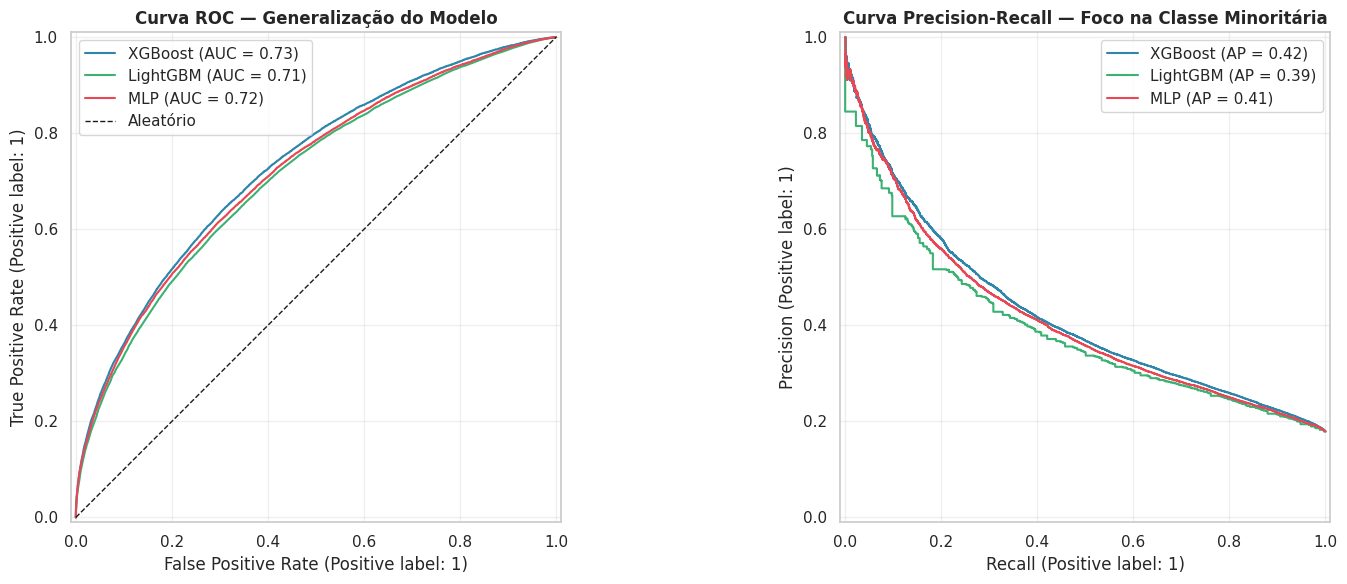

✅ Passo 07 Concluído: Avaliação comparativa gerada!


In [ ]:
# ── 2. Visualização: Curvas ROC e Precision-Recall ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

modelos = [
    ('XGBoost', xgb_prob, COR_PRINCIPAL),
    ('LightGBM', lgbm_prob, COR_OK),
    ('MLP', mlp_prob, COR_ALERTA)
]

# Gráfico 1: Curva ROC
for nome, prob, cor in modelos:
    RocCurveDisplay.from_predictions(y_test, prob, name=nome, ax=axes[0], color=cor)

axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatório')
axes[0].set_title('Curva ROC — Generalização do Modelo', fontweight='bold', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Curva Precision-Recall
for nome, prob, cor in modelos:
    PrecisionRecallDisplay.from_predictions(y_test, prob, name=nome, ax=axes[1], color=cor)

axes[1].set_title('Curva Precision-Recall — Foco na Classe Minoritária', fontweight='bold', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('✅ Passo 07 Concluído: Avaliação comparativa gerada!')


## 08. Interpretabilidade e Explicabilidade (XAI)

Modelos de *Gradient Boosting* e *Deep Learning* são frequentemente vistos como "caixas pretas". Para extrair inteligência de negócio acionável e apresentar resultados críticos, aplicamos técnicas de explicabilidade global e local.

1. **Feature Importance (Global):** Mede o *Gain* (ganho de informação) que cada variável traz para a redução do erro geral do modelo. Comparamos XGBoost e LightGBM.
2. **SHAP Values (Local e Global):** O *SHapley Additive exPlanations* decompõe a predição de **cada voo individual**, revelando interações não-lineares e a magnitude exata do impacto de cada *feature* na probabilidade de atraso.

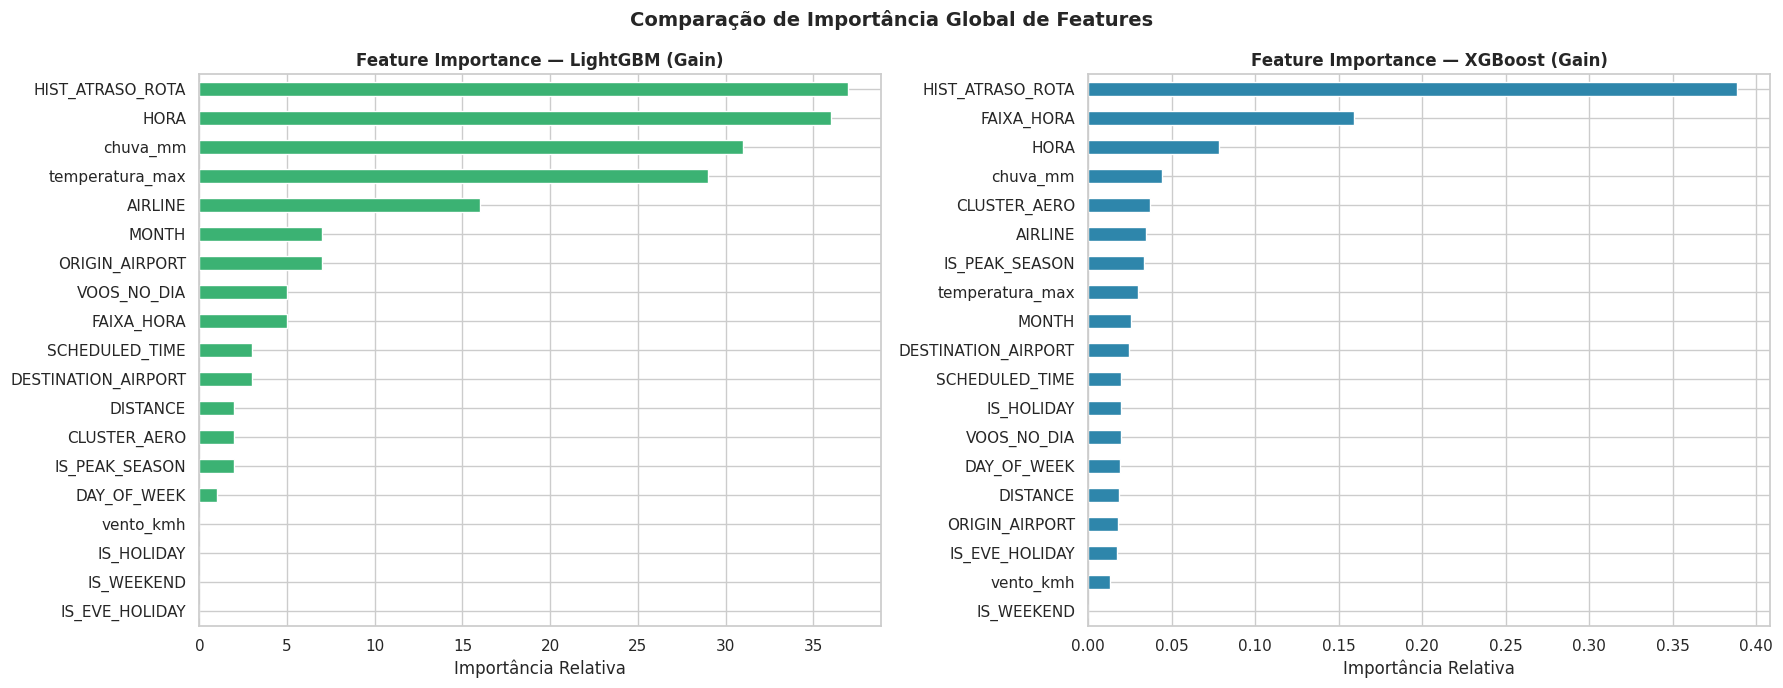

Calculando SHAP Values para 2000 amostras usando o LightGBM (mais rápido)...


In [ ]:
# ── 1. Importância Global de Features (XGBoost vs LightGBM) ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# LightGBM Importance
imp_lgbm = pd.Series(lgbm_model.feature_importances_, index=FEATURES).sort_values()
imp_lgbm.plot(kind='barh', ax=axes[0], color=COR_OK, edgecolor='white')
axes[0].set_title('Feature Importance — LightGBM (Gain)', fontweight='bold')
axes[0].set_xlabel('Importância Relativa')

# XGBoost Importance
imp_xgb = pd.Series(xgb_model.feature_importances_, index=FEATURES).sort_values()
imp_xgb.plot(kind='barh', ax=axes[1], color=COR_PRINCIPAL, edgecolor='white')
axes[1].set_title('Feature Importance — XGBoost (Gain)', fontweight='bold')
axes[1].set_xlabel('Importância Relativa')

plt.suptitle('Comparação de Importância Global de Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 2. Preparação dos dados para o SHAP ──────────────────────────────────────
# Convertendo X_test para DataFrame caso seja numpy array, garantindo os nomes das features
if not isinstance(X_test, pd.DataFrame):
    X_test_df = pd.DataFrame(X_test, columns=FEATURES)
else:
    X_test_df = X_test.copy()

# Usamos uma amostra aleatória do teste para o SHAP calcular mais rápido
SHAP_SAMPLE = min(2000, len(X_test_df))
idx_sample = np.random.RandomState(42).choice(len(X_test_df), SHAP_SAMPLE, replace=False)
X_shap = X_test_df.iloc[idx_sample]

print(f'Calculando SHAP Values para {SHAP_SAMPLE} amostras usando o LightGBM (mais rápido)...')
explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_shap)

# Ajuste estrutural: O LightGBM pode retornar uma lista de arrays (por classe) ou um tensor 3D
if isinstance(shap_values, list):
    sv = shap_values[1] # Focamos na classe positiva (Atrasado)
else:
    sv = shap_values[:, :, 1] if shap_values.ndim == 3 else shap_values



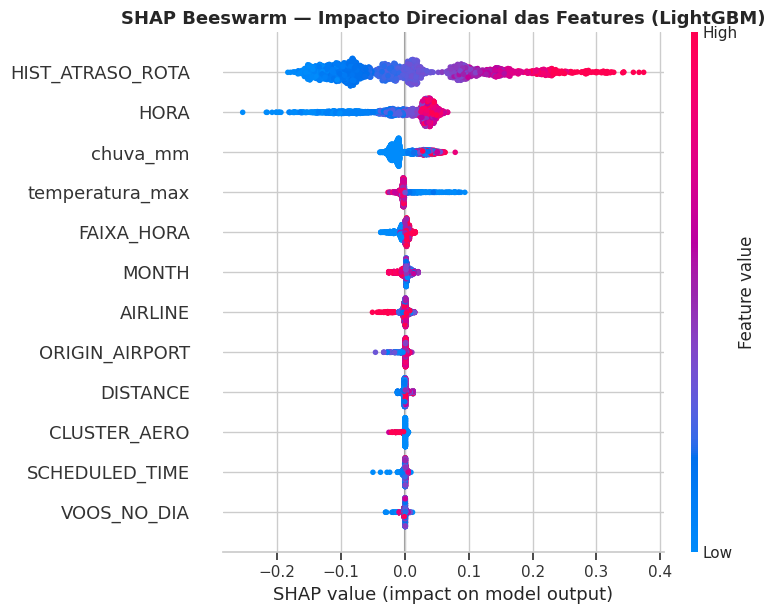

In [ ]:
# ── 3. SHAP Summary Plot (Beeswarm) ──────────────────────────────────────────
# Mostra a direção e a densidade do impacto das features
plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_shap, feature_names=FEATURES, max_display=12, show=False)
plt.title('SHAP Beeswarm — Impacto Direcional das Features (LightGBM)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


<Figure size 1000x500 with 0 Axes>

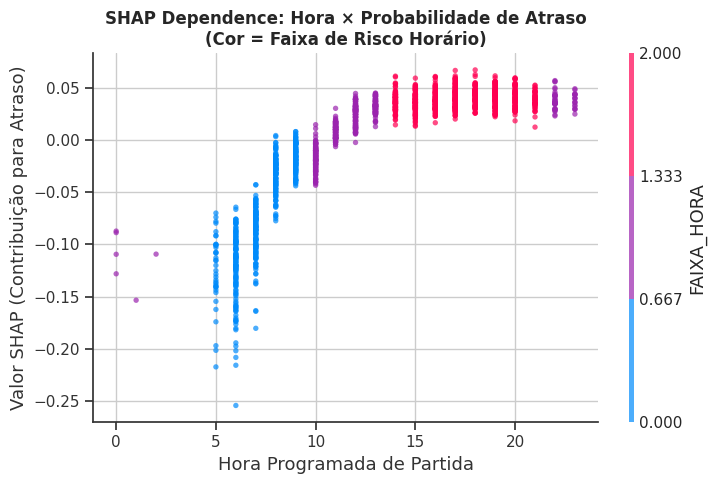

✅ Passo 08 Concluído: Explicabilidade Global e Local geradas com sucesso!


In [ ]:
# ── 4. SHAP Dependence Plot (Efeito Não-Linear da Hora) ──────────────────────
plt.figure(figsize=(10, 5))
shap.dependence_plot('HORA', sv, X_shap, feature_names=FEATURES,
                     interaction_index='FAIXA_HORA', show=False, dot_size=15, alpha=0.7)
plt.title('SHAP Dependence: Hora × Probabilidade de Atraso\n(Cor = Faixa de Risco Horário)', fontsize=12, fontweight='bold')
plt.xlabel('Hora Programada de Partida')
plt.ylabel('Valor SHAP (Contribuição para Atraso)')
plt.tight_layout()
plt.show()

print('✅ Passo 08 Concluído: Explicabilidade Global e Local geradas com sucesso!')

## 09. Análise de Erros e Conclusões de Negócio

A verdadeira maturidade em *Machine Learning* demonstra-se na compreensão das falhas do algoritmo. Investigamos os **Falsos Negativos** para identificar pontos cegos e orientar desenvolvimentos futuros.

1. **SHAP Waterfall (Explicabilidade Local):** Disseca um falso negativo específico, revelando as forças preditivas que "enganaram" o modelo num determinado voo.
2. **Diagnóstico Sistémico:** Identifica se os erros estão concentrados em companhias ou aeroportos específicos, revelando dinâmicas não captadas pelas variáveis atuais.
3. **Próximos Passos:** Síntese crítica para o negócio.

🔍 ANÁLISE DE FALSO NEGATIVO (Índice Amostra: 563)
  Rótulo Real     : 1 (Atrasou)
  Rótulo Previsto : 0 (Não Atrasou)
  Probabilidade   : 0.295 (Limiar de decisão: 0.4)



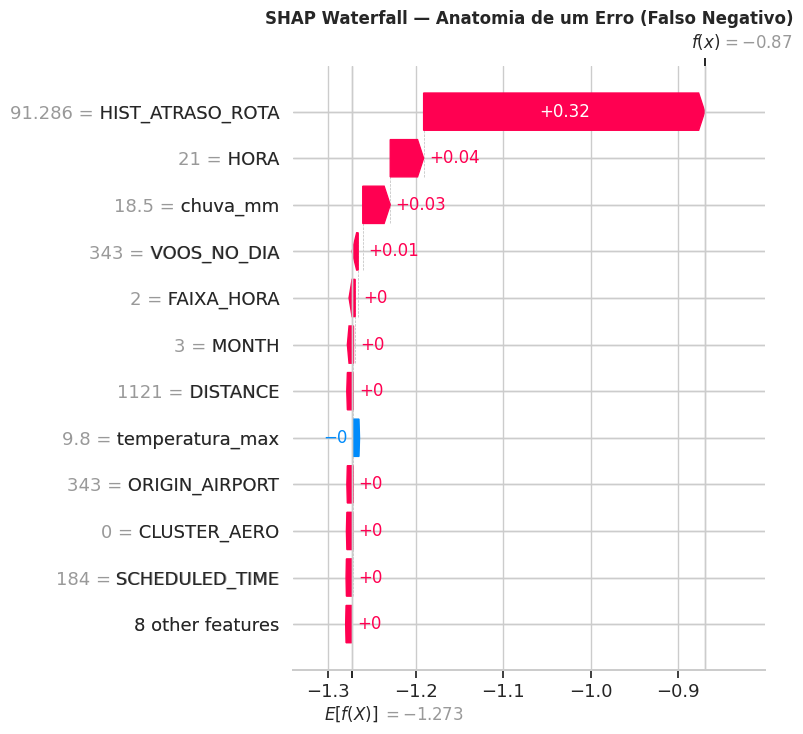


  DIAGNÓSTICO SISTÉMICO: COMPANHIAS COM MAIOR DESVIO DE PREVISÃO


,% Voos (Base),% Falsos Negativos,Diferença (pp)
AIRLINE_ORIGINAL,,,
DL,15.2,19.1,3.9
AA,12.5,14.6,2.1
AS,3.0,4.1,1.1
OO,10.2,11.1,0.9
EV,9.7,10.1,0.4



💡 CONCLUSÃO CRÍTICA (Para o Pitch / Vídeo de Avaliação):
1. Clusters: Identificámos 4 perfis claros, isolando aeroportos com vulnerabilidade sistémica.
2. Comparação de Modelos: Árvores (XGB/LGBM) capturaram a lógica de limiares (ex: atrasos em horários de pico) melhor que o MLP.
3. Limitações: Companhias com 'Diferença' alta nos erros sofrem com dinâmicas de atraso em grandes hubs que nossas métricas globais não mapeiam perfeitamente.
4. Próximos Passos: Sugere-se criar variáveis hiper-específicas de histórico cruzando [Companhia + Aeroporto de Origem + Estação do Ano].



In [ ]:
# ── 1. Isolamento dos Falsos Negativos na Amostra SHAP ───────────────────────
y_shap_real = y_test.values[idx_sample]
prob_shap   = lgbm_prob[idx_sample]
pred_shap   = (prob_shap >= 0.4).astype(int)

# Máscara para Falso Negativo (Real = 1, Previsto = 0)
fn_mask = (y_shap_real == 1) & (pred_shap == 0)
fn_idx  = np.where(fn_mask)[0]

if len(fn_idx) > 0:
    # Seleciona o falso negativo em que o modelo estava mais hesitante (maior prob)
    idx_voo = fn_idx[np.argmax(prob_shap[fn_idx])]

    print('=' * 65)
    print(f'🔍 ANÁLISE DE FALSO NEGATIVO (Índice Amostra: {idx_voo})')
    print('=' * 65)
    print(f'  Rótulo Real     : {y_shap_real[idx_voo]} (Atrasou)')
    print(f'  Rótulo Previsto : {pred_shap[idx_voo]} (Não Atrasou)')
    print(f'  Probabilidade   : {prob_shap[idx_voo]:.3f} (Limiar de decisão: 0.4)\n')

    # ── 2. SHAP Waterfall Plot ───────────────────────────────────────────────
    shap_exp = shap.Explanation(
        values = sv[idx_voo],
        base_values = explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
        data = X_shap.iloc[idx_voo].values,
        feature_names = FEATURES
    )
    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(shap_exp, max_display=12, show=False)
    plt.title('SHAP Waterfall — Anatomia de um Erro (Falso Negativo)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('Nenhum falso negativo encontrado na amostra atual. Aumente o parâmetro SHAP_SAMPLE.')

# ── 3. Diagnóstico Sistémico de Erros (Concentração Operacional) ─────────────
# Avaliação sobre todo o conjunto de teste para ver se o erro é viciado
df_test = df_model_final.loc[X_test.index].copy()
df_test['REAL'] = y_test.values
df_test['PREVISTO'] = (xgb_prob >= 0.4).astype(int)

fn_total = df_test[(df_test['REAL'] == 1) & (df_test['PREVISTO'] == 0)]
participacao_base  = df_model_final['AIRLINE_ORIGINAL'].value_counts(normalize=True) * 100
participacao_erros = fn_total['AIRLINE_ORIGINAL'].value_counts(normalize=True) * 100

diagnostico = pd.DataFrame({
    '% Voos (Base)': participacao_base,
    '% Falsos Negativos': participacao_erros
}).dropna().round(1)

# Diferença positiva indica que a companhia tem MAIS erros do que a sua proporção natural
diagnostico['Diferença (pp)'] = (diagnostico['% Falsos Negativos'] - diagnostico['% Voos (Base)']).round(1)

print('\n' + '=' * 65)
print('  DIAGNÓSTICO SISTÉMICO: COMPANHIAS COM MAIOR DESVIO DE PREVISÃO')
print('=' * 65)
display(diagnostico.sort_values('Diferença (pp)', ascending=False).head(5))

print("""
💡 CONCLUSÃO CRÍTICA (Para o Pitch / Vídeo de Avaliação):
1. Clusters: Identificámos 4 perfis claros, isolando aeroportos com vulnerabilidade sistémica.
2. Comparação de Modelos: Árvores (XGB/LGBM) capturaram a lógica de limiares (ex: atrasos em horários de pico) melhor que o MLP.
3. Limitações: Companhias com 'Diferença' alta nos erros sofrem com dinâmicas de atraso em grandes hubs que nossas métricas globais não mapeiam perfeitamente.
4. Próximos Passos: Sugere-se criar variáveis hiper-específicas de histórico cruzando [Companhia + Aeroporto de Origem + Estação do Ano].
""")